# 12. 수작업 특징의 초기 MP3 실험

기존 LR·SVM과 Validation 임계값을 고정하고 같은 Test 곡을 원본 배포 파일, MP3 128 kbps, 64 kbps로 비교한다. 여기서 ‘원본’은 무손실 오디오를 뜻하지 않는다. 최신 네 모델의 paired 실험은 24B에 기록했다.

In [1]:
from pathlib import Path
import json
import subprocess
import shutil
import time

import joblib
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")

SEGMENT_PATH = PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"
ORIGINAL_FEATURE_PATH = (
    PROJECT_ROOT / "data/processed/features/handcrafted_features_10s.csv"
)

BASELINE_MODEL_DIR = PROJECT_ROOT / "checkpoints/baseline"
BASELINE_RESULT_DIR = PROJECT_ROOT / "results/baseline"

SCALER_PATH = BASELINE_MODEL_DIR / "standard_scaler_handcrafted.joblib"
LR_MODEL_PATH = BASELINE_MODEL_DIR / "logistic_regression.joblib"
SVM_MODEL_PATH = BASELINE_MODEL_DIR / "rbf_svm.joblib"
THRESHOLD_PATH = BASELINE_RESULT_DIR / "eer_thresholds.json"

COMPRESSED_ROOT = PROJECT_ROOT / "data/processed/mp3_robustness"
FEATURE_DIR = PROJECT_ROOT / "data/processed/features/mp3_robustness"
RESULT_DIR = PROJECT_ROOT / "results/mp3_robustness"

COMPRESSED_ROOT.mkdir(parents=True, exist_ok=True)
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

BITRATES = {
    "mp3_128": "128k",
    "mp3_64": "64k",
}

SR = 24_000
SEGMENT_SEC = 10.0
TARGET_SAMPLES = int(SR * SEGMENT_SEC)

N_FFT = 1024
HOP_LENGTH = 240
N_MELS = 128
N_MFCC = 40
FMAX = 12_000

print("SEGMENT_PATH :", SEGMENT_PATH)
print("COMPRESSED   :", COMPRESSED_ROOT)
print("RESULT_DIR   :", RESULT_DIR)

SEGMENT_PATH : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/data/metadata/segment_manifest_10s.csv
COMPRESSED   : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/data/processed/mp3_robustness
RESULT_DIR   : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/mp3_robustness


## 1. 필요한 파일 및 ffmpeg 확인

In [2]:
# 필요한 파일 및 ffmpeg 확인
required_paths = [
    SEGMENT_PATH,
    ORIGINAL_FEATURE_PATH,
    SCALER_PATH,
    LR_MODEL_PATH,
    SVM_MODEL_PATH,
    THRESHOLD_PATH,
]

for p in required_paths:
    print(p.name, "->", p.exists())

FFMPEG_AVAILABLE = shutil.which("ffmpeg") is not None
print("\nffmpeg available:", FFMPEG_AVAILABLE)

if not FFMPEG_AVAILABLE:
    raise RuntimeError(
        "ffmpeg가 필요합니다. Mac 터미널에서 `brew install ffmpeg` 후 다시 실행하세요."
    )

segment_manifest_10s.csv -> True
handcrafted_features_10s.csv -> True
standard_scaler_handcrafted.joblib -> True
logistic_regression.joblib -> True
rbf_svm.joblib -> True
eer_thresholds.json -> True

ffmpeg available: True


## 2. Test segment / track 구조 로드

압축 강건성 실험은 **Test split만** 사용한다.

In [3]:
segments = pd.read_csv(SEGMENT_PATH)

# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
test_segments = segments[segments["split"] == "test"].copy()

test_tracks = (
    test_segments[
        [
            "track_sample_id",
            "audio_path",
            "label",
            "label_id",
            "original_audio",
            "genre",
            "generator",
        ]
    ]
    .drop_duplicates("track_sample_id")
    .reset_index(drop=True)
)

print("===== TEST STRUCTURE =====")
print("Test segments:", len(test_segments))
print("Test tracks  :", len(test_tracks))
print("REAL tracks  :", int((test_tracks["label"] == "REAL").sum()))
print("FAKE tracks  :", int((test_tracks["label"] == "FAKE").sum()))

display(test_tracks.head())

===== TEST STRUCTURE =====
Test segments: 1572
Test tracks  : 539
REAL tracks  : 45
FAKE tracks  : 494


,track_sample_id,audio_path,label,label_id,original_audio,genre,generator
0,sample_00003,data/raw/FMA/selected_30s/114/114244.mp3,REAL,0,2Much (Andy Spinelli & Alex Sánchez House Edit...,Electronic,NaN
1,sample_00004,data/raw/FMA/selected_30s/112/112378.mp3,REAL,0,3 am West End - statusq,Electronic,NaN
2,sample_00005,data/raw/FMA/selected_30s/066/066445.mp3,REAL,0,5 (Lexington) - Isle of Pine,Rock,NaN
3,sample_00021,data/raw/FMA/selected_30s/118/118048.mp3,REAL,0,Attention - Pete Prodoehl,Rock,NaN
4,sample_00028,data/raw/FMA/selected_30s/001/001881.mp3,REAL,0,Bizzy - The Tleilaxu Music Machine,Electronic,NaN


## 3. MP3 재인코딩 경로 생성

원래 디렉터리 구조를 그대로 복제하지 않고,
`track_sample_id.mp3` 형식으로 별도 저장한다.

예:

```text
data/processed/mp3_robustness/mp3_128/sample_00001.mp3
data/processed/mp3_robustness/mp3_64/sample_00001.mp3
```

원본 파일은 수정하지 않는다.

In [4]:
# MP3 재인코딩 경로 생성
def compressed_path(condition, track_sample_id):
    return COMPRESSED_ROOT / condition / f"{track_sample_id}.mp3"


preview = test_tracks.iloc[0]

for condition in BITRATES:
    print(condition, "->", compressed_path(condition, preview["track_sample_id"]))

mp3_128 -> /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/data/processed/mp3_robustness/mp3_128/sample_00003.mp3
mp3_64 -> /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/data/processed/mp3_robustness/mp3_64/sample_00003.mp3


## 4. MP3 재인코딩 함수

`libmp3lame`을 사용하여 고정 bitrate로 인코딩한다.

중요:
- 원본 파일은 변경하지 않음
- sample rate/channel은 ffmpeg가 원본 특성을 기반으로 처리
- 모델 입력 시에는 기존과 동일하게 librosa에서 24 kHz mono로 변환

In [5]:
# MP3 재인코딩 함수
def transcode_mp3(src: Path, dst: Path, bitrate: str):
    if dst.exists() and dst.stat().st_size > 0:
        return True, "already_exists"

    dst.parent.mkdir(parents=True, exist_ok=True)

    temp = dst.with_suffix(".part.mp3")

    if temp.exists():
        temp.unlink()

    cmd = [
        "ffmpeg",
        "-y",
        "-v",
        "error",
        "-i",
        str(src),
        "-codec:a",
        "libmp3lame",
        "-b:a",
        bitrate,
        str(temp),
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        if temp.exists():
            temp.unlink()

        return False, result.stderr.strip()

    if not temp.exists() or temp.stat().st_size == 0:
        return False, "output_not_created"

    temp.replace(dst)

    return True, "encoded"

## 5. 먼저 2곡만 재인코딩 테스트

전체 Test 539곡을 처리하기 전에
REAL 1곡 + FAKE 1곡으로 128k / 64k 변환이 정상인지 확인한다.

In [6]:
# 먼저 2곡만 재인코딩 테스트
test_examples = pd.concat(
    [
        test_tracks[test_tracks["label"] == "REAL"].head(1),
        test_tracks[test_tracks["label"] == "FAKE"].head(1),
    ],
    ignore_index=True,
)

transcode_test_rows = []

for _, row in test_examples.iterrows():
    src = PROJECT_ROOT / row["audio_path"]

    for condition, bitrate in BITRATES.items():
        dst = compressed_path(condition, row["track_sample_id"])

        ok, status = transcode_mp3(
            src,
            dst,
            bitrate,
        )

        transcode_test_rows.append(
            {
                "track_sample_id": row["track_sample_id"],
                "label": row["label"],
                "condition": condition,
                "bitrate": bitrate,
                "ok": ok,
                "status": status,
                "size_bytes": (dst.stat().st_size if dst.exists() else np.nan),
            }
        )

display(pd.DataFrame(transcode_test_rows))

,track_sample_id,label,condition,bitrate,ok,status,size_bytes
0,sample_00003,REAL,mp3_128,128k,True,encoded,481373
1,sample_00003,REAL,mp3_64,64k,True,encoded,241046
2,sample_00298,FAKE,mp3_128,128k,True,encoded,1292589
3,sample_00298,FAKE,mp3_64,64k,True,encoded,646317


## 6. Test 전체 539곡 MP3 재인코딩

이미 생성된 파일은 자동으로 건너뛴다.
따라서 중간에 중단되어도 같은 셀을 다시 실행할 수 있다.

In [7]:
transcode_rows = []

total_jobs = len(test_tracks) * len(BITRATES)
job_index = 0

for _, row in test_tracks.iterrows():
    src = PROJECT_ROOT / row["audio_path"]

    for condition, bitrate in BITRATES.items():
        job_index += 1

        dst = compressed_path(condition, row["track_sample_id"])

        if not src.exists():
            ok = False
            status = "source_not_found"
        else:
            ok, status = transcode_mp3(
                src,
                dst,
                bitrate,
            )

        transcode_rows.append(
            {
                "track_sample_id": row["track_sample_id"],
                "label": row["label"],
                "source_path": row["audio_path"],
                "condition": condition,
                "bitrate": bitrate,
                "compressed_path": str(dst.relative_to(PROJECT_ROOT)),
                "ok": ok,
                "status": status,
                "size_bytes": (dst.stat().st_size if dst.exists() else np.nan),
            }
        )

        if job_index % 100 == 0 or job_index == total_jobs:
            print(f"transcoded: {job_index}/{total_jobs}")

transcode_report = pd.DataFrame(transcode_rows)

display(pd.crosstab(transcode_report["condition"], transcode_report["ok"]))

transcode_report.to_csv(
    RESULT_DIR / "transcode_report.csv",
    index=False,
    encoding="utf-8-sig",
)

transcoded: 100/1078
transcoded: 200/1078
transcoded: 300/1078
transcoded: 400/1078
transcoded: 500/1078
transcoded: 600/1078
transcoded: 700/1078
transcoded: 800/1078
transcoded: 900/1078
transcoded: 1000/1078
transcoded: 1078/1078


ok,True
condition,
mp3_128,539
mp3_64,539


## 7. 재인코딩 QC

In [8]:
# 재인코딩 QC
failed_transcodes = transcode_report[~transcode_report["ok"]].copy()

print("Total jobs :", len(transcode_report))
print("Successful :", int(transcode_report["ok"].sum()))
print("Failed     :", len(failed_transcodes))

if len(failed_transcodes):
    display(failed_transcodes.head(30))

Total jobs : 1078
Successful : 1078
Failed     : 0


## 8. Feature 추출 함수 재사용

08단계와 동일한 feature 정의를 사용한다.

**Feature 정의가 달라지면 압축 조건 비교가 불가능하므로 반드시 동일해야 한다.**

In [9]:
# Feature 추출 함수 재사용
def add_mean_std(feature_dict, prefix, x):
    x = np.asarray(x)

    if x.ndim == 1:
        x = x[np.newaxis, :]

    for i in range(x.shape[0]):
        name = f"{prefix}_{i+1:02d}" if x.shape[0] > 1 else prefix

        feature_dict[f"{name}_mean"] = float(np.mean(x[i]))
        feature_dict[f"{name}_std"] = float(np.std(x[i]))


def extract_handcrafted_features(y):
    features = {}

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=SR,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmax=FMAX,
    )

    mfcc_delta = librosa.feature.delta(mfcc, order=1)

    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    add_mean_std(features, "mfcc", mfcc)
    add_mean_std(features, "mfcc_delta", mfcc_delta)
    add_mean_std(features, "mfcc_delta2", mfcc_delta2)

    centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
    )

    bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
    )

    rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        roll_percent=0.85,
    )

    flatness = librosa.feature.spectral_flatness(
        y=y,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
    )

    contrast = librosa.feature.spectral_contrast(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
    )

    rms = librosa.feature.rms(
        y=y,
        frame_length=N_FFT,
        hop_length=HOP_LENGTH,
    )

    zcr = librosa.feature.zero_crossing_rate(
        y=y,
        frame_length=N_FFT,
        hop_length=HOP_LENGTH,
    )

    add_mean_std(features, "spectral_centroid", centroid)
    add_mean_std(features, "spectral_bandwidth", bandwidth)
    add_mean_std(features, "spectral_rolloff", rolloff)
    add_mean_std(features, "spectral_flatness", flatness)
    add_mean_std(features, "spectral_contrast", contrast)
    add_mean_std(features, "rms", rms)
    add_mean_std(features, "zcr", zcr)

    return features

## 9. 압축 파일용 10초 segment 로딩

기존 segment manifest의 `start_sec` 위치를 그대로 사용한다.

MP3 재인코딩 후 몇 ms 정도 길이가 달라질 수 있으므로
부족한 경우 zero-padding한다.

In [10]:
# 압축 파일용 10초 segment 로딩
def load_compressed_segment(
    compressed_audio_path: Path,
    start_sec: float,
):
    y, _ = librosa.load(
        compressed_audio_path,
        sr=SR,
        mono=True,
        offset=float(start_sec),
        duration=SEGMENT_SEC,
    )

    y = np.asarray(y, dtype=np.float32)

    if len(y) < TARGET_SAMPLES:
        y = np.pad(
            y,
            (0, TARGET_SAMPLES - len(y)),
            mode="constant",
        )
    elif len(y) > TARGET_SAMPLES:
        y = y[:TARGET_SAMPLES]

    return y

## 10. 압축 조건별 Feature 추출

각 조건별로 Test 1,572개 segment의 266개 feature를 다시 추출한다.

조건별 checkpoint CSV를 저장하므로
완료된 조건은 다시 추출하지 않는다.

In [11]:
META_COLUMNS = [
    "segment_id",
    "track_sample_id",
    "original_audio",
    "label",
    "label_id",
    "source",
    "genre",
    "generator",
    "split",
    "segment_index",
    "segment_role",
    "start_sec",
    "end_sec",
]


def extract_condition_features(condition):
    output_path = FEATURE_DIR / f"handcrafted_test_{condition}.csv"

    if output_path.exists():
        existing = pd.read_csv(output_path)

        if len(existing) == len(test_segments) and existing[
            "segment_id"
        ].nunique() == len(test_segments):
            print(condition, "feature file already complete.")
            return existing

    rows = []

    for n, (_, seg) in enumerate(test_segments.iterrows(), start=1):
        audio_file = compressed_path(condition, seg["track_sample_id"])

        result = {col: seg[col] for col in META_COLUMNS if col in seg.index}

        result["condition"] = condition
        result["error"] = ""

        try:
            y = load_compressed_segment(audio_file, seg["start_sec"])

            feats = extract_handcrafted_features(y)

            result.update(feats)

        except Exception as e:
            result["error"] = f"{type(e).__name__}: {e}"

        rows.append(result)

        if n % 250 == 0 or n == len(test_segments):
            print(f"{condition}: " f"{n}/{len(test_segments)}")

            pd.DataFrame(rows).to_csv(
                output_path,
                index=False,
                encoding="utf-8-sig",
            )

    return pd.DataFrame(rows)


compressed_features = {}

for condition in BITRATES:
    print("\n" + "=" * 70)
    print("FEATURE EXTRACTION:", condition)
    print("=" * 70)

    compressed_features[condition] = extract_condition_features(condition)


FEATURE EXTRACTION: mp3_128
mp3_128: 250/1572
mp3_128: 500/1572
mp3_128: 750/1572
mp3_128: 1000/1572
mp3_128: 1250/1572
mp3_128: 1500/1572
mp3_128: 1572/1572

FEATURE EXTRACTION: mp3_64
mp3_64: 250/1572


[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2432) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2304) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2368) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2304) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2400) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2368) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2272) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2464) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776]

mp3_64: 500/1572
mp3_64: 750/1572


[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2208) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2240) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2720) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2304) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2336) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2304) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2944) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (2272) too large for available bit count (2200)
[src/libmpg123/layer3.c:INT123_do_layer3():1776]

mp3_64: 1000/1572
mp3_64: 1250/1572
mp3_64: 1500/1572
mp3_64: 1572/1572


## 11. 압축 Feature QC

In [12]:
# 압축 Feature QC
feature_qc_rows = []

for condition, feature_df in compressed_features.items():
    failed = feature_df[feature_df["error"].fillna("").str.len() > 0]

    feature_columns = [
        c
        for c in feature_df.columns
        if (
            c.startswith("mfcc_")
            or c.startswith("mfcc_delta_")
            or c.startswith("mfcc_delta2_")
            or c.startswith("spectral_")
            or c.startswith("rms_")
            or c.startswith("zcr_")
        )
    ]

    numeric = feature_df[feature_columns].apply(pd.to_numeric, errors="coerce")

    feature_qc_rows.append(
        {
            "condition": condition,
            "rows": len(feature_df),
            "unique_segment_id": feature_df["segment_id"].nunique(),
            "feature_columns": len(feature_columns),
            "failures": len(failed),
            "nan_values": int(numeric.isna().sum().sum()),
            "inf_values": int(np.isinf(numeric.to_numpy(dtype=float)).sum()),
        }
    )

feature_qc = pd.DataFrame(feature_qc_rows)

display(feature_qc)

,condition,rows,unique_segment_id,feature_columns,failures,nan_values,inf_values
0,mp3_128,1572,1572,266,0,0,0
1,mp3_64,1572,1572,266,0,0,0


## 12. 기존 scaler / baseline 모델 / threshold 로드

**재학습하지 않는다.**

In [13]:
# 기존 scaler / baseline 모델 / threshold 로드
scaler = joblib.load(SCALER_PATH)
lr_model = joblib.load(LR_MODEL_PATH)
svm_model = joblib.load(SVM_MODEL_PATH)

with open(THRESHOLD_PATH, "r", encoding="utf-8") as f:
    thresholds = json.load(f)

threshold_lookup = {
    ("LogisticRegression", "segment"): float(
        thresholds["LogisticRegression"]["segment_eer_threshold"]
    ),
    ("LogisticRegression", "track"): float(
        thresholds["LogisticRegression"]["track_eer_threshold"]
    ),
    ("RBF-SVM", "segment"): float(thresholds["RBF-SVM"]["segment_eer_threshold"]),
    ("RBF-SVM", "track"): float(thresholds["RBF-SVM"]["track_eer_threshold"]),
}

print(threshold_lookup)

{('LogisticRegression', 'segment'): 0.6663391213946953, ('LogisticRegression', 'track'): 0.6059354207239731, ('RBF-SVM', 'segment'): 0.9258082151422282, ('RBF-SVM', 'track'): 0.8784699961277153}


## 13. 평가 함수

In [14]:
def find_eer(y_true, scores):
    # ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
    fpr, tpr, local_thresholds = roc_curve(
        y_true,
        scores,
        pos_label=1,
    )

    fnr = 1.0 - tpr

    valid = np.isfinite(local_thresholds)

    fpr = fpr[valid]
    fnr = fnr[valid]

    idx = np.argmin(np.abs(fpr - fnr))

    return float((fpr[idx] + fnr[idx]) / 2.0)


def evaluate_scores(
    y_true,
    scores,
    fixed_threshold,
):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    y_pred = (scores >= fixed_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
        "eer": find_eer(y_true, scores),
        "threshold_used": float(fixed_threshold),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "real_fpr": float(fp / (fp + tn)),
        "fake_miss_rate": float(fn / (fn + tp)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def make_track_scores(
    meta_df,
    scores,
):
    temp = meta_df[
        [
            "track_sample_id",
            "original_audio",
            "label",
            "label_id",
            "genre",
            "generator",
            "split",
        ]
    ].copy()

    temp["score"] = scores

    return temp.groupby("track_sample_id", as_index=False).agg(
        original_audio=("original_audio", "first"),
        label=("label", "first"),
        label_id=("label_id", "first"),
        genre=("genre", "first"),
        generator=("generator", "first"),
        split=("split", "first"),
        segment_count=("score", "size"),
        score=("score", "mean"),
    )

## 14. Original Test feature 준비

Original condition은 08단계에서 이미 추출한 feature를 재사용한다.

In [15]:
original_features_all = pd.read_csv(ORIGINAL_FEATURE_PATH)

# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
original_test = original_features_all[original_features_all["split"] == "test"].copy()

FEATURE_COLUMNS = sorted(
    [
        c
        for c in original_test.columns
        if (
            c.startswith("mfcc_")
            or c.startswith("mfcc_delta_")
            or c.startswith("mfcc_delta2_")
            or c.startswith("spectral_")
            or c.startswith("rms_")
            or c.startswith("zcr_")
        )
    ]
)

print("Original test rows:", len(original_test))
print("Feature columns   :", len(FEATURE_COLUMNS))

assert len(original_test) == 1572
assert len(FEATURE_COLUMNS) == 266

Original test rows: 1572
Feature columns   : 266


## 15. 세 조건 평가 실행

각 조건에서:
- 기존 scaler transform
- 기존 LR / SVM predict
- 기존 Validation threshold 적용
- segment-level 평가
- track-level 평균 aggregation 평가

In [16]:
condition_feature_map = {
    "original": original_test,
    **compressed_features,
}

result_rows = []
prediction_outputs = {}

for condition, feature_df in condition_feature_map.items():
    print("\nCondition:", condition)

    X = feature_df[FEATURE_COLUMNS].to_numpy(dtype=np.float64)

    y = feature_df["label_id"].astype(int).to_numpy()

    # Validation/Test에는 Train의 표준화 기준만 적용해 정보 누수를 막는다.
    X_scaled = scaler.transform(X)

    model_score_map = {
        # `predict_proba`로 각 클래스의 예측 확률을 얻는다.
        "LogisticRegression": (lr_model.predict_proba(X_scaled)[:, 1]),
        "RBF-SVM": (svm_model.predict_proba(X_scaled)[:, 1]),
    }

    for model_name, scores in model_score_map.items():
        # Segment
        segment_threshold = threshold_lookup[(model_name, "segment")]

        segment_metrics = evaluate_scores(
            y,
            scores,
            segment_threshold,
        )

        result_rows.append(
            {
                "condition": condition,
                "model": model_name,
                "level": "segment",
                **segment_metrics,
            }
        )

        # Track
        track_scores = make_track_scores(
            feature_df,
            scores,
        )

        track_threshold = threshold_lookup[(model_name, "track")]

        track_metrics = evaluate_scores(
            track_scores["label_id"],
            track_scores["score"],
            track_threshold,
        )

        result_rows.append(
            {
                "condition": condition,
                "model": model_name,
                "level": "track",
                **track_metrics,
            }
        )

        prediction_outputs[(condition, model_name, "segment")] = (
            feature_df,
            scores,
            segment_threshold,
        )

        prediction_outputs[(condition, model_name, "track")] = (
            track_scores,
            track_scores["score"].to_numpy(),
            track_threshold,
        )

robustness_results = pd.DataFrame(result_rows)

display(
    robustness_results[
        [
            "condition",
            "model",
            "level",
            "roc_auc",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
            "threshold_used",
        ]
    ]
    .sort_values(["model", "level", "condition"])
    .round(4)
)


Condition: original

Condition: mp3_128

Condition: mp3_64


,condition,model,level,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,threshold_used
4,mp3_128,LogisticRegression,segment,0.8597,0.2135,0.7798,0.6560,0.2741,0.1663,0.6663
8,mp3_64,LogisticRegression,segment,0.8152,0.2498,0.7471,0.6014,0.2741,0.2317,0.6663
0,original,LogisticRegression,segment,0.8776,0.1988,0.7946,0.6633,0.2444,0.1663,0.6663
5,mp3_128,LogisticRegression,track,0.8961,0.1830,0.8534,0.7545,0.2000,0.0931,0.6059
9,mp3_64,LogisticRegression,track,0.8507,0.2022,0.7756,0.6265,0.2444,0.2045,0.6059
1,original,LogisticRegression,track,0.9176,0.1385,0.8615,0.7523,0.1778,0.0992,0.6059
6,mp3_128,RBF-SVM,segment,0.9162,0.1629,0.8428,0.7233,0.1926,0.1218,0.9258
10,mp3_64,RBF-SVM,segment,0.8691,0.2289,0.7687,0.5901,0.1926,0.2700,0.9258
2,original,RBF-SVM,segment,0.9262,0.1475,0.8463,0.7115,0.1704,0.1371,0.9258
7,mp3_128,RBF-SVM,track,0.9536,0.1325,0.8676,0.7692,0.1778,0.0870,0.8785


## 16. 핵심 결과 — RBF-SVM Track-level

현재 handcrafted baseline의 대표 설정을 중심으로
Original → 128k → 64k 성능 변화를 확인한다.

In [17]:
# 핵심 결과 — RBF-SVM Track-level
svm_track_robustness = robustness_results[
    (robustness_results["model"] == "RBF-SVM")
    & (robustness_results["level"] == "track")
].copy()

condition_order = pd.CategoricalDtype(
    ["original", "mp3_128", "mp3_64"],
    ordered=True,
)

svm_track_robustness["condition"] = svm_track_robustness["condition"].astype(
    condition_order
)

svm_track_robustness = svm_track_robustness.sort_values("condition")

display(
    svm_track_robustness[
        [
            "condition",
            "roc_auc",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
        ]
    ].round(4)
)

,condition,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate
3,original,0.9644,0.1395,0.8696,0.7502,0.1556,0.1053
7,mp3_128,0.9536,0.1325,0.8676,0.7692,0.1778,0.0870
11,mp3_64,0.9062,0.1688,0.8494,0.7437,0.2000,0.1012


## 17. Original 대비 성능 하락 계산

In [18]:
# Original 대비 성능 하락 계산
original_row = svm_track_robustness[
    svm_track_robustness["condition"] == "original"
].iloc[0]

robustness_compare = svm_track_robustness[
    [
        "condition",
        "roc_auc",
        "eer",
        "balanced_accuracy",
        "macro_f1",
        "real_fpr",
        "fake_miss_rate",
    ]
].copy()

robustness_compare["roc_auc_drop"] = (
    original_row["roc_auc"] - robustness_compare["roc_auc"]
)

robustness_compare["eer_increase"] = robustness_compare["eer"] - original_row["eer"]

robustness_compare["balanced_accuracy_drop"] = (
    original_row["balanced_accuracy"] - robustness_compare["balanced_accuracy"]
)

robustness_compare["fake_miss_increase"] = (
    robustness_compare["fake_miss_rate"] - original_row["fake_miss_rate"]
)

display(robustness_compare.round(4))

,condition,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,roc_auc_drop,eer_increase,balanced_accuracy_drop,fake_miss_increase
3,original,0.9644,0.1395,0.8696,0.7502,0.1556,0.1053,0.0000,0.0000,0.0000,0.0000
7,mp3_128,0.9536,0.1325,0.8676,0.7692,0.1778,0.0870,0.0108,-0.0071,0.0020,-0.0182
11,mp3_64,0.9062,0.1688,0.8494,0.7437,0.2000,0.1012,0.0583,0.0293,0.0202,-0.0040


## 18. 압축 조건별 ROC-AUC 시각화

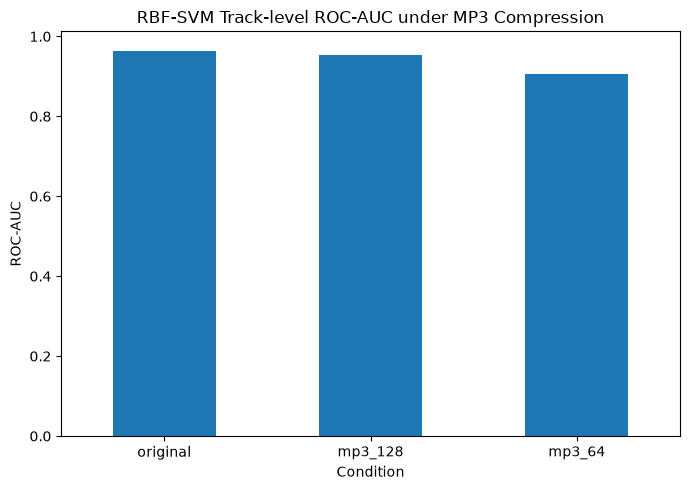

In [19]:
plot_df = svm_track_robustness.set_index("condition")

ax = plot_df["roc_auc"].plot(
    kind="bar",
    figsize=(7, 5),
    rot=0,
    title="RBF-SVM Track-level ROC-AUC under MP3 Compression",
)

ax.set_ylabel("ROC-AUC")
ax.set_xlabel("Condition")

plt.tight_layout()
plt.show()

## 19. 압축 조건별 오류율 시각화

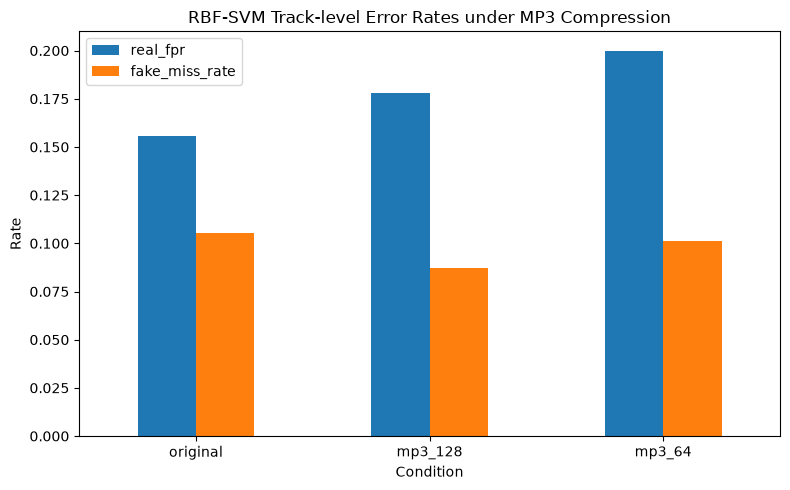

In [20]:
error_plot = svm_track_robustness.set_index("condition")[
    [
        "real_fpr",
        "fake_miss_rate",
    ]
]

ax = error_plot.plot(
    kind="bar",
    figsize=(8, 5),
    rot=0,
    title="RBF-SVM Track-level Error Rates under MP3 Compression",
)

ax.set_ylabel("Rate")
ax.set_xlabel("Condition")

plt.tight_layout()
plt.show()

## 20. Segment vs Track 압축 강건성 비교

압축 환경에서도 track aggregation이 도움이 되는지 확인한다.

In [21]:
# Segment vs Track 압축 강건성 비교
svm_comparison = robustness_results[robustness_results["model"] == "RBF-SVM"].pivot(
    index="condition",
    columns="level",
    values=[
        "roc_auc",
        "eer",
        "balanced_accuracy",
        "fake_miss_rate",
    ],
)

display(svm_comparison.round(4))

roc_auc             eer         balanced_accuracy          \
level     segment   track segment   track           segment   track   
condition                                                             
mp3_128    0.9162  0.9536  0.1629  0.1325            0.8428  0.8676   
mp3_64     0.8691  0.9062  0.2289  0.1688            0.7687  0.8494   
original   0.9262  0.9644  0.1475  0.1395            0.8463  0.8696   

          fake_miss_rate          
level            segment   track  
condition                         
mp3_128           0.1218  0.0870  
mp3_64            0.2700  0.1012  
original          0.1371  0.1053

## 21. Generator별 압축 영향 — Track-level RBF-SVM

압축에 특히 민감한 generator가 있는지 추가로 확인한다.

각 generator에 대해:
- 해당 generator FAKE Test
- 전체 REAL Test

를 사용한다.

Threshold는 동일한 global track threshold를 고정한다.

In [22]:
# Generator별 압축 영향 — Track-level RBF-SVM
def evaluate_generator_track(
    track_df,
    fixed_threshold,
):
    real_df = track_df[track_df["label"] == "REAL"]

    fake_df = track_df[track_df["label"] == "FAKE"]

    rows = []

    for generator in sorted(fake_df["generator"].dropna().unique()):
        subgroup = pd.concat(
            [
                real_df,
                fake_df[fake_df["generator"] == generator],
            ],
            ignore_index=True,
        )

        metrics = evaluate_scores(
            subgroup["label_id"],
            subgroup["score"],
            fixed_threshold,
        )

        rows.append(
            {
                "generator": generator,
                **metrics,
            }
        )

    return pd.DataFrame(rows)


generator_condition_results = []

for condition in ["original", "mp3_128", "mp3_64"]:
    track_df, _, threshold = prediction_outputs[(condition, "RBF-SVM", "track")]

    generator_metrics = evaluate_generator_track(
        track_df,
        threshold,
    )

    generator_metrics["condition"] = condition

    generator_condition_results.append(generator_metrics)

generator_compression = pd.concat(
    generator_condition_results,
    ignore_index=True,
)

generator_auc_table = generator_compression.pivot(
    index="generator",
    columns="condition",
    values="roc_auc",
)

display(generator_auc_table.round(4))

condition,mp3_128,mp3_64,original
generator,,,
acestep,0.9783,0.9304,0.9886
audioldm,0.9980,0.9911,1.0000
brev,0.9542,0.8796,0.9694
diffrhythm,0.9797,0.8161,0.9863
elevenlabs,0.8829,0.8227,0.8968
mubert,0.9333,0.9111,0.9528
musicgen,0.9906,0.9802,0.9951
producer,0.9493,0.9058,0.9591
songgen,0.9877,0.9719,0.9921


## 22. 결과 저장

In [23]:
robustness_results.to_csv(
    RESULT_DIR / "mp3_robustness_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

robustness_compare.to_csv(
    RESULT_DIR / "rbf_svm_track_robustness_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

generator_compression.to_csv(
    RESULT_DIR / "generator_compression_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

generator_auc_table.to_csv(
    RESULT_DIR / "generator_compression_auc_table.csv",
    encoding="utf-8-sig",
)

print("Saved results to:", RESULT_DIR)

Saved results to: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/mp3_robustness


## 23. 최종 Robustness QC

In [24]:
# 최종 Robustness QC
qc_summary = pd.DataFrame(
    {
        "check": [
            "test_tracks",
            "test_segments",
            "transcode_jobs",
            "failed_transcodes",
            "mp3_128_feature_rows",
            "mp3_64_feature_rows",
            "mp3_128_feature_failures",
            "mp3_64_feature_failures",
            "robustness_result_rows",
            "conditions",
        ],
        "value": [
            len(test_tracks),
            len(test_segments),
            len(transcode_report),
            len(failed_transcodes),
            len(compressed_features["mp3_128"]),
            len(compressed_features["mp3_64"]),
            int(
                compressed_features["mp3_128"]["error"].fillna("").str.len().gt(0).sum()
            ),
            int(
                compressed_features["mp3_64"]["error"].fillna("").str.len().gt(0).sum()
            ),
            len(robustness_results),
            robustness_results["condition"].nunique(),
        ],
    }
)

display(qc_summary)

robustness_qc_pass = (
    len(test_tracks) == 539
    and len(test_segments) == 1572
    and len(failed_transcodes) == 0
    and len(compressed_features["mp3_128"]) == len(test_segments)
    and len(compressed_features["mp3_64"]) == len(test_segments)
    and (compressed_features["mp3_128"]["error"].fillna("").str.len().gt(0).sum() == 0)
    and (compressed_features["mp3_64"]["error"].fillna("").str.len().gt(0).sum() == 0)
    and robustness_results["condition"].nunique() == 3
)

print("===== FINAL RESULT =====")
print("MP3 Robustness Core QC PASS:", robustness_qc_pass)

,check,value
0,test_tracks,539
1,test_segments,1572
2,transcode_jobs,1078
3,failed_transcodes,0
4,mp3_128_feature_rows,1572
5,mp3_64_feature_rows,1572
6,mp3_128_feature_failures,0
7,mp3_64_feature_failures,0
8,robustness_result_rows,12
9,conditions,3


===== FINAL RESULT =====
MP3 Robustness Core QC PASS: True


## 이어지는 기록

13번에서는 수작업 특징 대신 Log-Mel을 입력으로 한 CNN을 살펴본다.

## 초기 MP3 결과

RBF-SVM Track-level 압축 강건성 결과다.

| 조건 | ROC-AUC | EER | Balanced Accuracy |
|---|---:|---:|---:|
| Original | 0.9644 | 0.1395 | 0.8696 |
| MP3 128 kbps | 0.9536 | 0.1325 | 0.8676 |
| MP3 64 kbps | 0.9062 | 0.1688 | 0.8494 |

- 128 kbps에서는 성능이 대체로 유지됐고, 64 kbps에서 ROC-AUC가 0.0583 하락했다.
- 모델과 threshold를 재학습하지 않아 차이는 codec shift에 대한 민감도로 해석한다.
- 결과를 `results/mp3_robustness/`에 저장했다.